In [13]:
############################
# Importaciones
############################
import os                                                   # Llamadas al SO.
import re                                                   # Extracción de nombres de dataset.
import sys                                                  # Límite de recursión (dendrogramas grandes).
from pathlib import Path                                    # Estructura para directorios.
import pandas as pd                                         # Manejo de dataframes.
import numpy as np                                          # Manejo de datos numericos.
import matplotlib.pyplot as plt                             # Gráficos.
import seaborn as sns                                       # Heatmaps clusterizados.
import fastcluster                                          # Linkage jerárquico rápido.
from scipy import stats                                     # Pruebas estadísticas generales.
from scipy.spatial.distance import squareform               # Conversión matriz <-> condensada.
from IPython.display import display                         # Interfaz para mostrar resultados.

############################
# Detección de entorno (Colab / Local)
############################
# En Colab (incluido VSCode conectado a un runtime de Colab) el repositorio se
# encuentra clonado en /content/Thesis. En local, se busca la raíz del
# repositorio subiendo desde el directorio de trabajo actual.
try:
    import google.colab                                     # Módulo disponible solo dentro de runtimes de Colab.
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    THESIS_DIR = Path("/content/Thesis")
else:
    _cwd = Path(os.getcwd()).resolve()
    THESIS_DIR = next(
        (p for p in (_cwd, *_cwd.parents) if (p / "Datasets").is_dir() and (p / "Source Code").is_dir()),
        None,
    )
    if THESIS_DIR is None:
        raise FileNotFoundError(f"No se encontró la raíz del repositorio (Datasets/ y Source Code/) desde {_cwd}")

############################
# Constantes
############################
DATA_DIR          = Path(os.getcwd()).resolve() / "Datasets" / "Gene_Expression_source"
OUTPUT_DIR_PREFIX = DATA_DIR / "Results"
MATRICES_DIR = THESIS_DIR / "Datasets" / ("matrices" if IN_COLAB else "Matrices")
print(f"[entorno] {'Colab' if IN_COLAB else 'Local'} → {THESIS_DIR}")

# Matrices de información biológica (_S_DB) y de expresión (_S_DE) disponibles.
# Se descubren automáticamente todos los datasets que tengan AMBOS archivos.
_db_nombres = {
    m.group(1)
    for f in MATRICES_DIR.glob("*_S_DB.npz")
    if (m := re.match(r"^(.+)_S_DB\.npz$", f.name))
}
_de_nombres = {
    m.group(1)
    for f in MATRICES_DIR.glob("*_S_DE.npz")
    if (m := re.match(r"^(.+)_S_DE\.npz$", f.name))
}
DATASETS = sorted(_db_nombres & _de_nombres)
print(f"[datasets] {len(DATASETS)} encontrados: {DATASETS}")

DB_PATHS = {nombre: MATRICES_DIR / f"{nombre}_S_DB.npz" for nombre in DATASETS}
DE_PATHS = {nombre: MATRICES_DIR / f"{nombre}_S_DE.npz" for nombre in DATASETS}

##################################
# Conjunto de funciones.
##################################

def load_distance_matrix(filepath):
    """
    Carga de matrices de distancias en versión comprimioda.
    """
    # Carga de los datos dentro del archivo.
    data = np.load(filepath, allow_pickle=True)
    genes = data["genes"].tolist()

    n = len(genes)                              # Orden de la matriz.
    iu = np.triu_indices(n, k=1)                # índices de la triangular superior.
    M = np.zeros((n, n), dtype=np.float32)      # Matriz nxn.

    # Carga de datos y completar valores de triangular inferior (como diagonal).
    M[iu] = data["upper"]
    M += M.T
    np.fill_diagonal(M, data["diag"])

    # Retroalimentación y sálida.
    print(f"[load] '{filepath.name}' → matriz {n}×{n}. Primer gen: '{genes[0]}', último: '{genes[-1]}'.")
    return 1 - M, genes


def plot_clustered_heatmap(matrix, title, cmap="viridis", figsize=(8, 8)):
    """
    Muestra un heatmap clusterizado (orden jerárquico por similitud) de una
    matriz de distancias ya cargada, directamente en el notebook.

    Se amplía temporalmente el límite de recursión, ya que
    scipy.cluster.hierarchy.dendrogram recorre el linkage de forma recursiva
    y con miles de hojas puede superar el límite por defecto de Python.
    """
    similarity = 1 - matrix
    dist_condensed = squareform(matrix, checks=False)
    linkage = fastcluster.linkage(dist_condensed, method="average")

    old_limit = sys.getrecursionlimit()
    sys.setrecursionlimit(max(old_limit, 100_000))
    try:
        g = sns.clustermap(
            similarity,
            row_linkage=linkage, col_linkage=linkage,
            cmap=cmap, xticklabels=False, yticklabels=False,
            figsize=figsize, rasterized=True,
        )
        g.fig.suptitle(title)
    finally:
        sys.setrecursionlimit(old_limit)

    display(g.fig)
    plt.close(g.fig)


def find_isolated_genes(similarity_matrix):
    """
    Genes aislados: aquellos cuya fila de similitud biológica es enteramente
    0 (omitiéndose a sí mismos, i.e. sin contar la diagonal).
    """
    n = similarity_matrix.shape[0]
    off_diag_mask = ~np.eye(n, dtype=bool)
    off_diag_values = similarity_matrix[off_diag_mask].reshape(n, n - 1)
    return np.where(np.all(off_diag_values == 0, axis=1))[0]


def impute_isolated_genes(bio_similarity, expr_similarity, k_fraction=0.10, k_min=1):
    """
    Imputa, para cada gen aislado (sin similitud biológica con nadie), su
    fila/columna en la matriz de Wang mediante "guilt-by-association" por
    expresión:

    Para el par (i, j) a imputar, se toman los TOP-k genes más similares
    según expresión a i y a j por separado, y el nuevo valor de Wang(i, j)
    es el promedio de la submatriz biológica k×k formada por esos vecinos
    (sin incluir al propio gen aislado, que no aporta información).

    k se calcula como k_fraction del tamaño del dataset (n genes), con un
    mínimo de k_min, de modo que se escala automáticamente según el tamaño
    de cada matriz en vez de usar un valor fijo.

    Devuelve una copia de bio_similarity con las filas/columnas de los
    genes aislados reemplazadas, junto a los índices aislados, sus vecinos
    y el k efectivamente usado.
    """
    n = bio_similarity.shape[0]
    k = max(k_min, round(n * k_fraction))

    # TOP-k vecinos por expresión de cada gen (excluyendo a sí mismo).
    expr_sim = expr_similarity.copy()
    np.fill_diagonal(expr_sim, -np.inf)
    vecinos = np.argsort(-expr_sim, axis=1)[:, :k]   # (n, k)

    isolados = find_isolated_genes(bio_similarity)
    M_new = bio_similarity.copy()

    # Los nuevos valores se calculan siempre a partir de la matriz original
    # (bio_similarity), para que el orden de procesamiento no afecte el
    # resultado cuando dos genes aislados interactúan entre sí.
    for i in isolados:
        filas_vecinas = bio_similarity[vecinos[i], :]     # (k, n)
        promedio_vecinos_i = filas_vecinas.mean(axis=0)   # (n,) promedio sobre vecinos de i, por gen destino
        fila_nueva = promedio_vecinos_i[vecinos].mean(axis=1)  # (n,) promedio adicional sobre vecinos de cada j
        fila_nueva[i] = M_new[i, i]                        # conserva la diagonal
        M_new[i, :] = fila_nueva
        M_new[:, i] = fila_nueva                           # simetría

    return M_new, isolados, vecinos, k

[entorno] Local → C:\Users\benjamin.gonzalez\Desktop\workspace\Thesis
[datasets] 5 encontrados: ['A1', 'A2', 'B1', 'B2', 'B3']


In [2]:
##################################
# Carga de matrices (todos los datasets disponibles — información biológica).
##################################
matrices_bi = {}
for nombre, ruta in DB_PATHS.items():
    matrices_bi[nombre] = load_distance_matrix(ruta)

[load] 'A1_S_DB.npz' → matriz 8018×8018. Primer gen: 'A1BG', último: 'ENSG00000285994'.
[load] 'A2_S_DB.npz' → matriz 2705×2705. Primer gen: 'AKT3', último: 'ENSG00000285928'.
[load] 'B1_S_DB.npz' → matriz 3187×3187. Primer gen: 'CDH2', último: 'ENSG00000285973'.
[load] 'B2_S_DB.npz' → matriz 3024×3024. Primer gen: 'A1BG', último: 'ENSG00000284779'.
[load] 'B3_S_DB.npz' → matriz 10616×10616. Primer gen: 'CDH2', último: 'ENSG00000285994'.


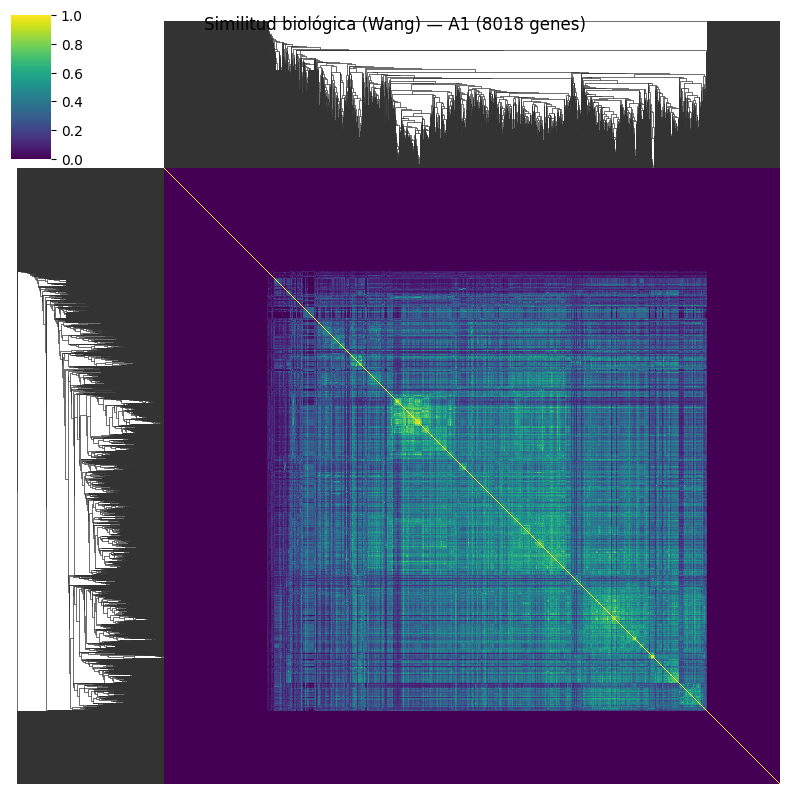

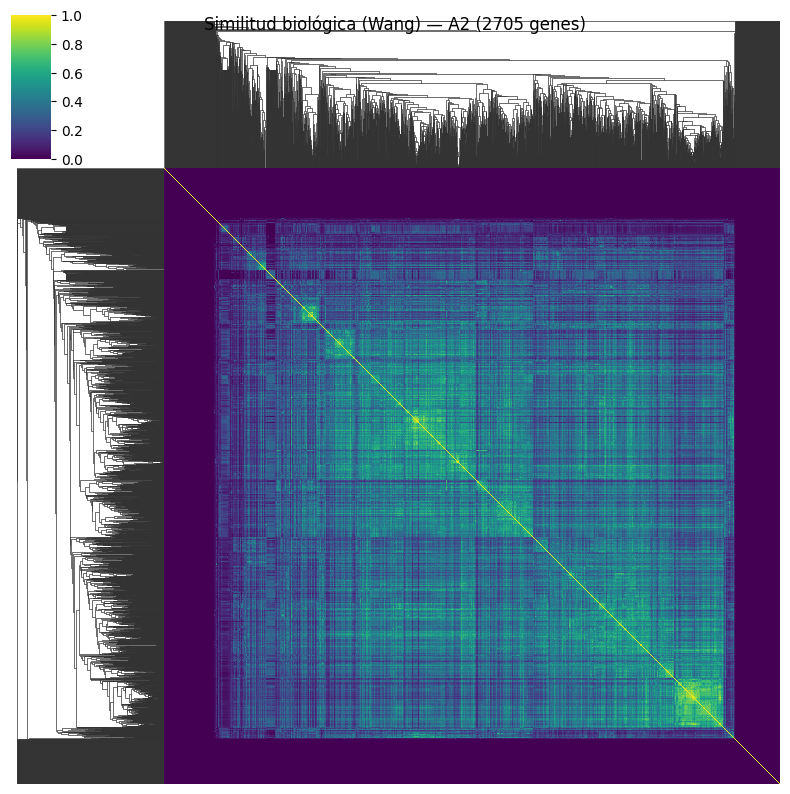

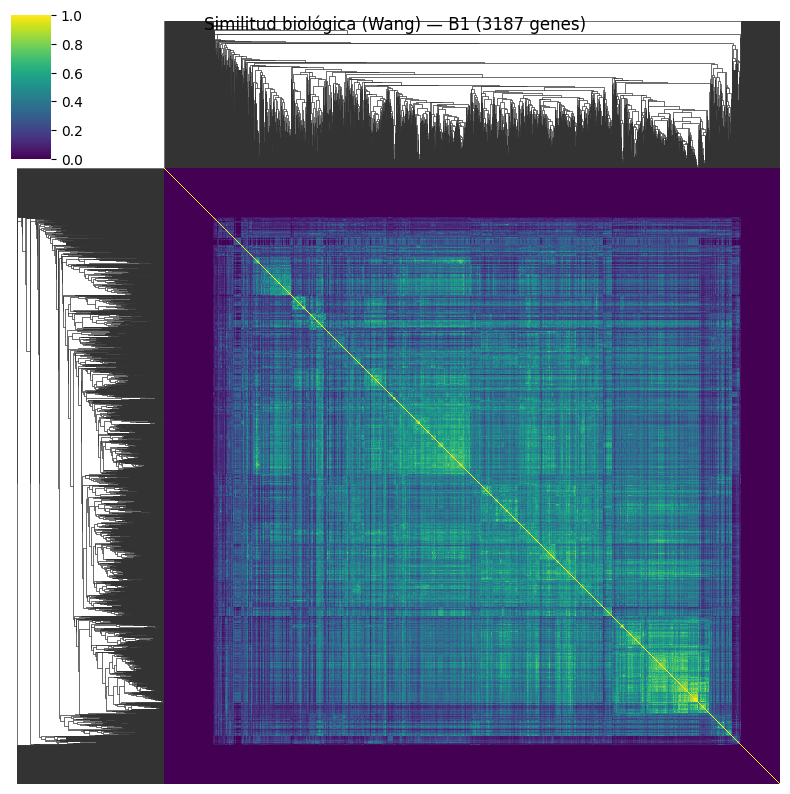

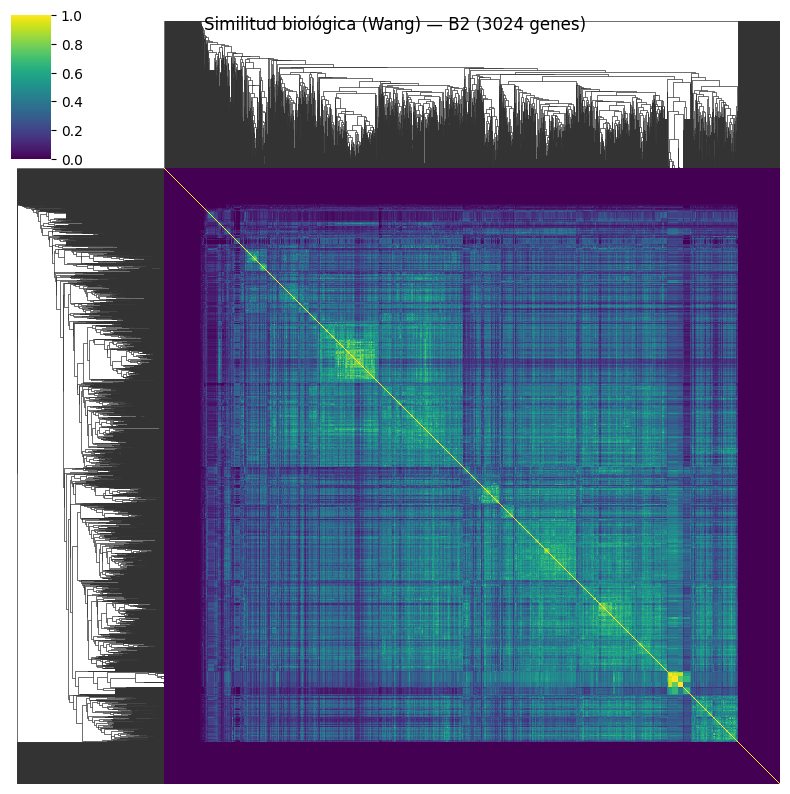

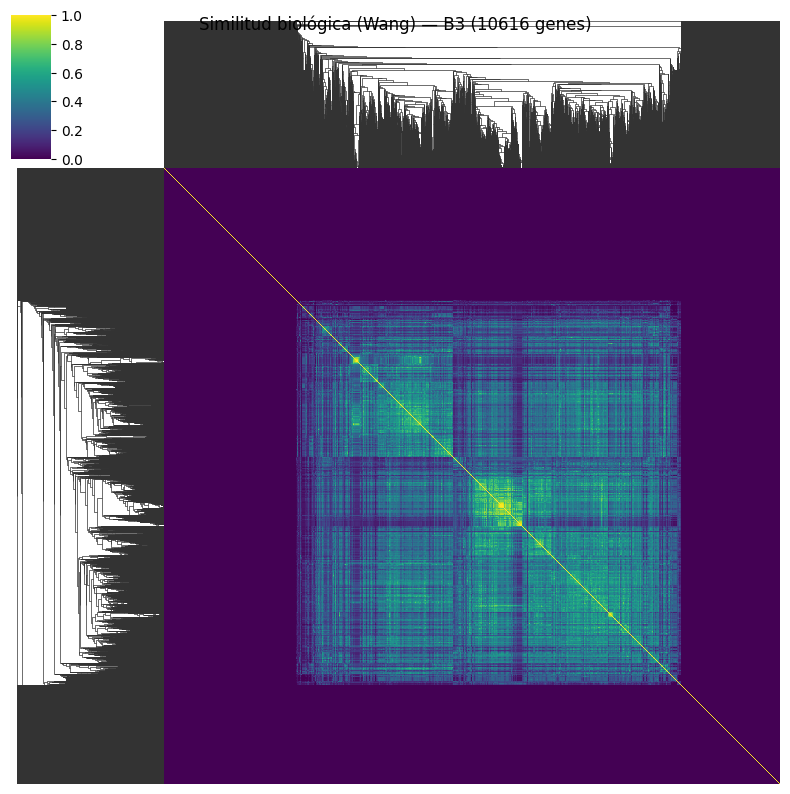

In [3]:
##################################
# Heatmaps clusterizados de similitud biológica (Wang) — todos los datasets.
##################################
for nombre, (distance_matrix, genes) in matrices_bi.items():
    plot_clustered_heatmap(
        distance_matrix,
        title=f"Similitud biológica (Wang) — {nombre} ({len(genes)} genes)",
    )

In [14]:
##################################
# Carga de matrices de expresión (todos los datasets) — para hallar vecinos por expresión.
##################################
matrices_de = {}
for nombre, ruta in DE_PATHS.items():
    matrices_de[nombre] = load_distance_matrix(ruta)

[load] 'A1_S_DE.npz' → matriz 8018×8018. Primer gen: 'A1BG', último: 'ENSG00000285994'.
[load] 'A2_S_DE.npz' → matriz 2705×2705. Primer gen: 'AKT3', último: 'ENSG00000285928'.
[load] 'B1_S_DE.npz' → matriz 3187×3187. Primer gen: 'CDH2', último: 'ENSG00000285973'.
[load] 'B2_S_DE.npz' → matriz 3024×3024. Primer gen: 'A1BG', último: 'ENSG00000284779'.
[load] 'B3_S_DE.npz' → matriz 10616×10616. Primer gen: 'CDH2', último: 'ENSG00000285994'.


In [15]:
##################################
# Imputación de genes aislados (biológica, vía TOP-10% vecinos de expresión).
##################################
matrices_bi_imputadas = {}
for nombre in DATASETS:
    distance_bi, genes = matrices_bi[nombre]
    distance_de, genes_de = matrices_de[nombre]
    assert genes == genes_de, f"Orden de genes distinto entre DB y DE para {nombre}."

    bio_similarity = 1 - distance_bi
    expr_similarity = 1 - distance_de

    bio_similarity_imputada, idx_aislados, vecinos, k = impute_isolated_genes(
        bio_similarity, expr_similarity, k_fraction=0.10,
    )
    print(f"[impute] {nombre}: {len(idx_aislados)}/{len(genes)} genes aislados imputados (k={k}).")

    matrices_bi_imputadas[nombre] = (1 - bio_similarity_imputada, genes)

[impute] A1: 2289/8018 genes aislados imputados (k=802).
[impute] A2: 416/2705 genes aislados imputados (k=270).
[impute] B1: 454/3187 genes aislados imputados (k=319).
[impute] B2: 385/3024 genes aislados imputados (k=302).
[impute] B3: 3984/10616 genes aislados imputados (k=1062).


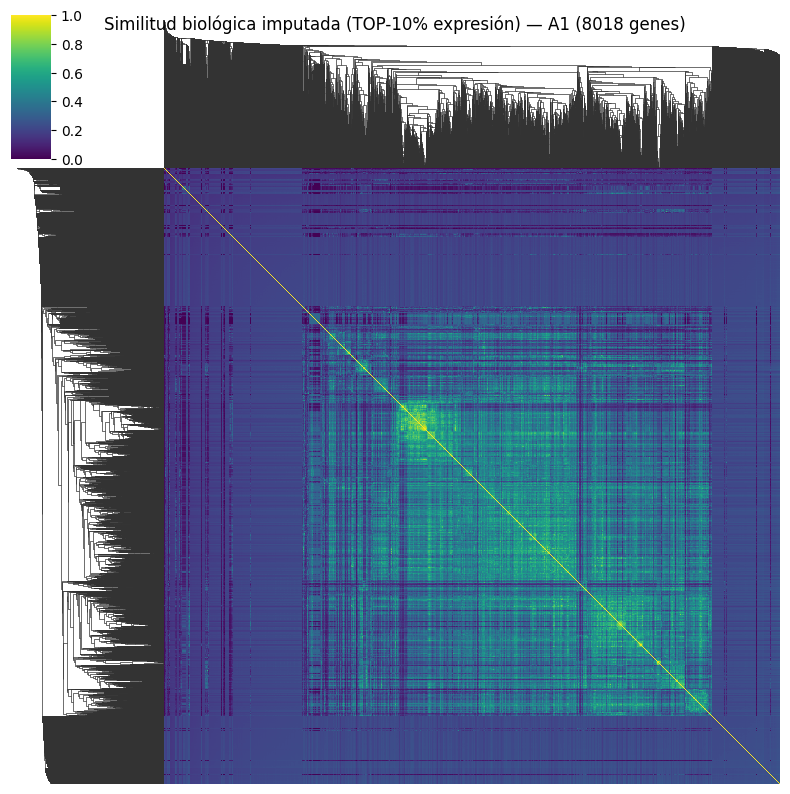

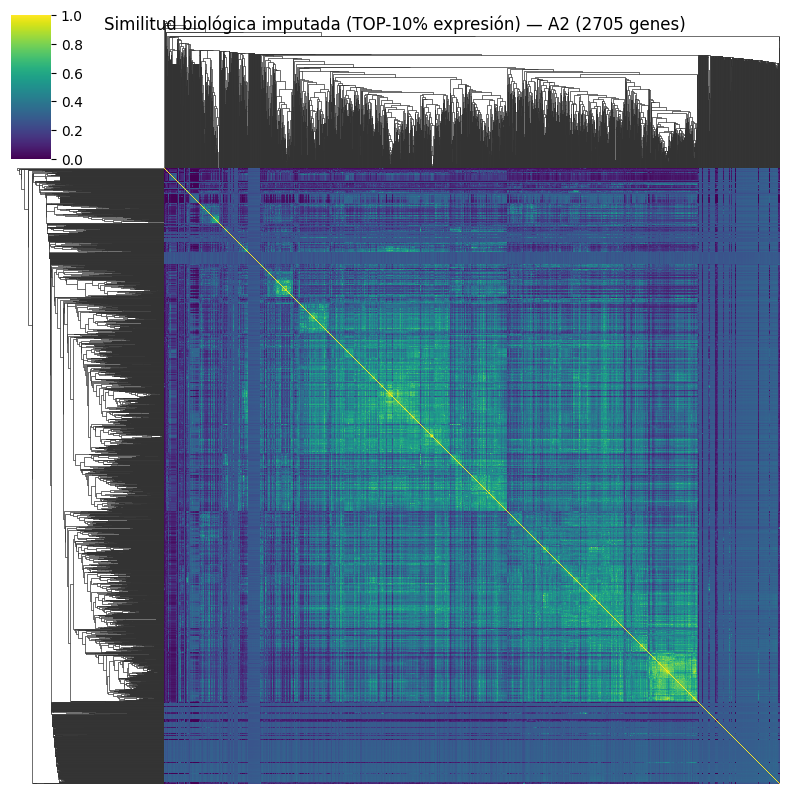

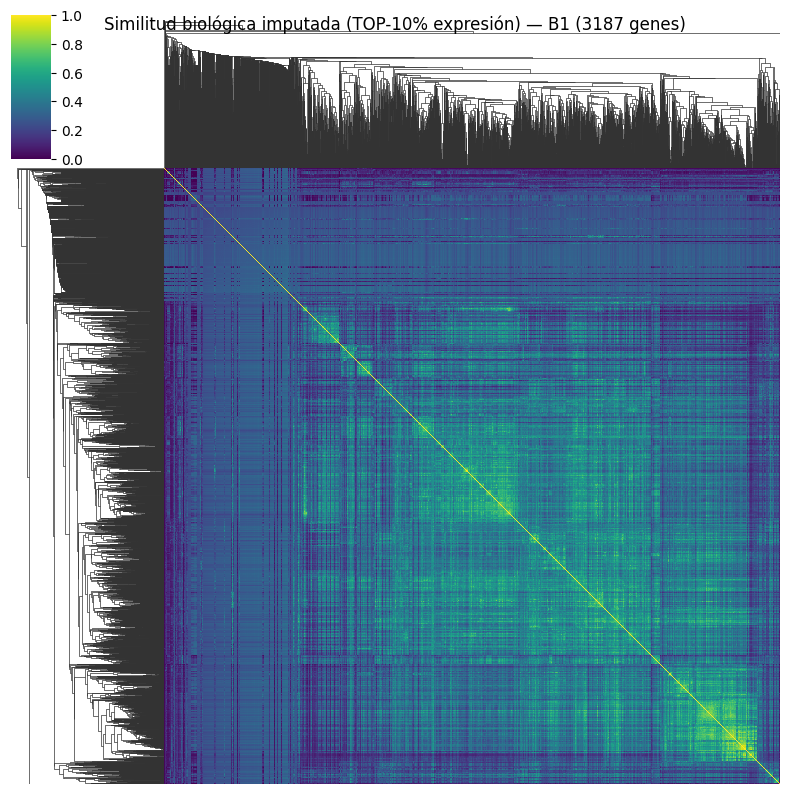

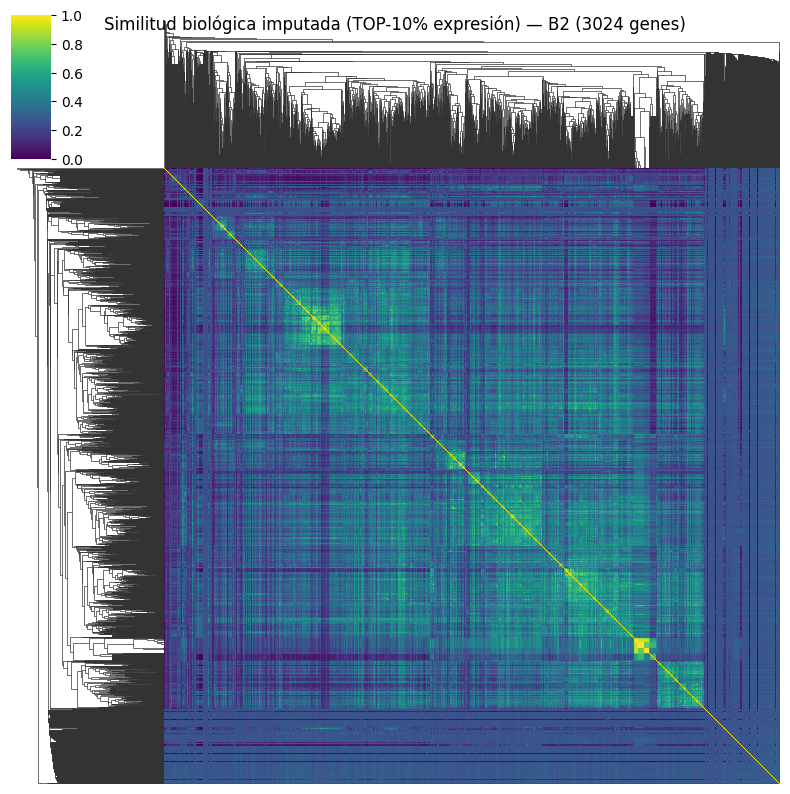

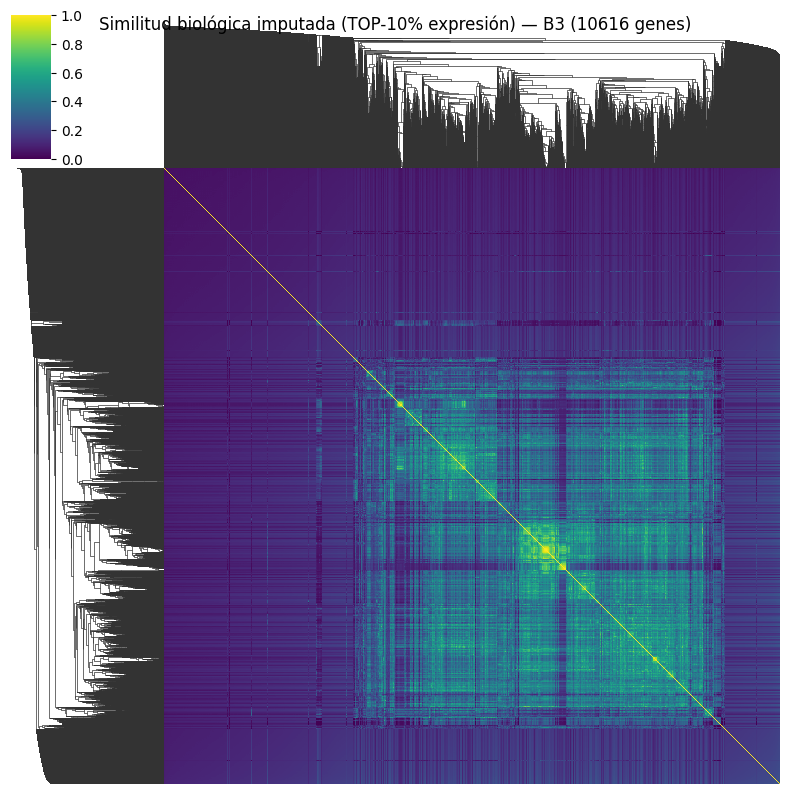

In [16]:
##################################
# Heatmaps clusterizados — matrices biológicas imputadas — todos los datasets.
##################################
for nombre, (distance_matrix, genes) in matrices_bi_imputadas.items():
    plot_clustered_heatmap(
        distance_matrix,
        title=f"Similitud biológica imputada (TOP-10% expresión) — {nombre} ({len(genes)} genes)",
    )